In [19]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from current_loop import current_loop
from loop_system import loop_system
from LC_series_in_para import LC_series_in_para

In [20]:
num_loops           = 10
axial_span          = np.pi / 2
coil_radius         = 0.1
wire_radius         = 0.002
measurement_radius  = 0.1
num_left_branch     = 5
num_right_branch    = 5

C                   = 42.88e-6            
V_0                 = 4_928.0                 
target_voltage      = 250.0                 # plot reference. Does not effect calculations

frames              = 361
fps                 = 20
z_res               = 4001

In [21]:
z_positions = np.linspace(-axial_span / 2, axial_span / 2, num_loops)

def zero_current(t):
    return np.zeros_like(t, dtype=float)

loops = []
for i, z_pos in enumerate(z_positions):
    loops.append(current_loop(
        name=f"Loop {i + 1}",
        radius=coil_radius,
        z_pos=z_pos,
        current=zero_current,
        dIdt=zero_current,
        wire_radius=wire_radius
    ))

system = loop_system(loops)
circuit = LC_series_in_para(C, V_0, system, num_left_branch, num_right_branch)

In [22]:
M = system.calc_inductance_mtrx()
n = num_left_branch
M_branches = np.array([
    [np.sum(M[:n, :n]), np.sum(M[:n, n:])],
    [np.sum(M[n:, :n]), np.sum(M[n:, n:])]
])
weights = np.linalg.solve(M_branches, np.ones(2))
L_eq = 1 / np.sum(weights)
print("Branch inductance matrix [microhenry]:")
print(M_branches * 1e6)

omega = 1 / np.sqrt(C * L_eq)
t_peak = np.pi / (2 * omega)
t_start = 0.0
t_stop = 2 * t_peak
min_z = z_positions[0] * 1.2
max_z = z_positions[-1] * 1.2

print(f"C = {C * 1e6:.5f} microfarad")
print(f"V_0 = {V_0:.3f} V")
print(f"First current peak = {t_peak * 1e6:.4f} microseconds")

Branch inductance matrix [microhenry]:
[[2.68710752 0.03482089]
 [0.03482089 2.68710752]]
C = 42.88000 microfarad
V_0 = 4928.000 V
First current peak = 11.9997 microseconds


In [23]:
voltage_anim = circuit.anim_loop_voltage(
    radius=measurement_radius,
    t_start=t_start,
    t_stop=t_stop,
    frames=frames,
    fps=fps,
    min_z=min_z,
    max_z=max_z,
    z_res=z_res,
    r_max=measurement_radius,
    r_res=2
)

Peak |bank current| = 27.661 kA


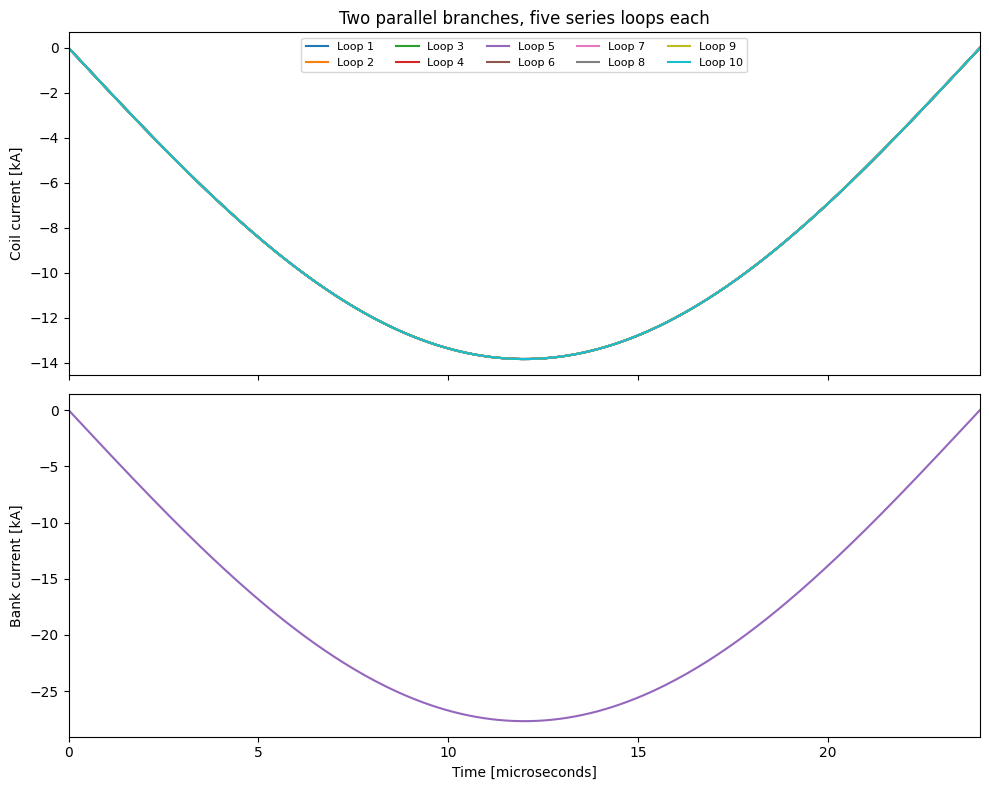

In [24]:
times = np.linspace(t_start, t_stop, frames)
I_loops = np.array([loop.current(times) for loop in loops])
I_bank = I_loops[0] + I_loops[num_left_branch]

print(f"Peak |bank current| = {np.max(np.abs(I_bank)) / 1e3:.3f} kA")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for i, waveform in enumerate(I_loops):
    axes[0].plot(times * 1e6, waveform / 1e3, label=f"Loop {i + 1}")
axes[0].set_ylabel("Coil current [kA]")
axes[0].legend(ncol=5, fontsize=8, loc="best")
axes[0].set_title("Two parallel branches, five series loops each")
axes[1].plot(times * 1e6, I_bank / 1e3, color="tab:purple")
axes[1].set_ylabel("Bank current [kA]")
axes[1].set_xlabel("Time [microseconds]")
axes[1].set_xlim(t_start * 1e6, t_stop * 1e6)

fig.tight_layout()
plt.show()

In [25]:
HTML(voltage_anim.to_jshtml())